# Web Scraping + Analysis (Job Postings) — 02 Analysis

What skills, roles, and companies dominate the current remote-job market? All numbers are run against the scraped snapshot.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import utils
df=utils.load_jobs()

## 1. Most in-demand tags / skills

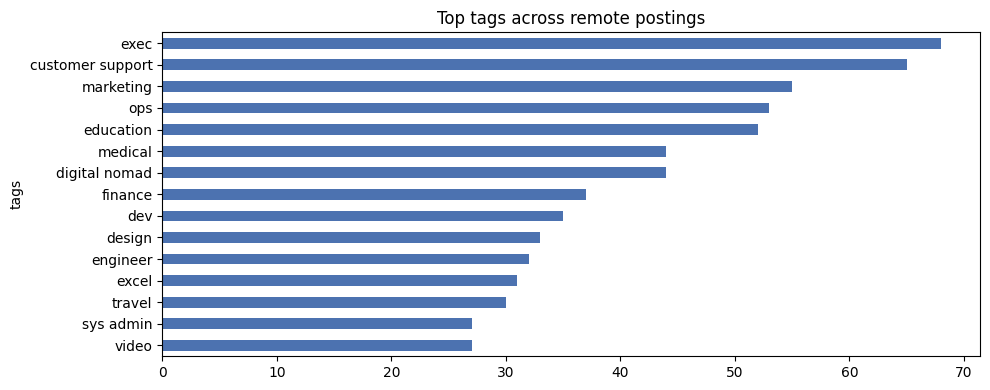

{'exec': 68, 'customer support': 65, 'marketing': 55, 'ops': 53, 'education': 52, 'medical': 44, 'digital nomad': 44, 'finance': 37}


In [2]:
tt=utils.top_tags(df,15)
fig,ax=plt.subplots(figsize=(10,4)); tt.plot(kind='barh',ax=ax,color='#4c72b0'); ax.invert_yaxis(); ax.set_title('Top tags across remote postings'); plt.tight_layout(); plt.show()
print(tt.head(8).to_dict())

## 2. Top hiring companies & common role words

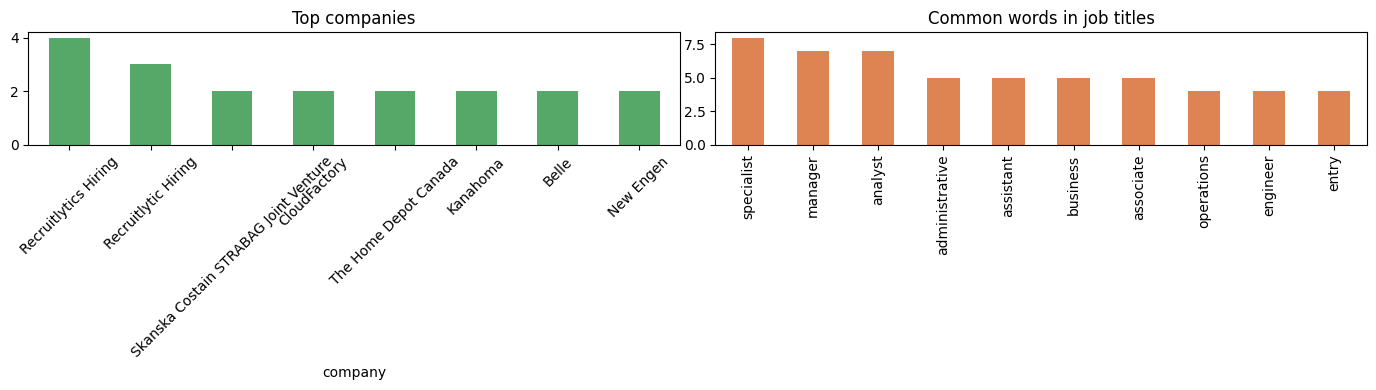

In [3]:
from collections import Counter
import re
fig,ax=plt.subplots(1,2,figsize=(14,4))
df.company.value_counts().head(8).plot(kind='bar',ax=ax[0],color='#55a868'); ax[0].set_title('Top companies'); ax[0].tick_params(axis='x',rotation=45)
words=Counter(w.lower() for t in df.position.dropna() for w in re.findall(r'[a-zA-Z]+',t) if len(w)>2)
pd.Series(dict(words.most_common(10))).plot(kind='bar',ax=ax[1],color='#dd8452'); ax[1].set_title('Common words in job titles')
plt.tight_layout(); plt.show()

## 3. Summary & takeaways

- **The scrape works end-to-end** — a single RemoteOK API call yields ~100 structured postings (role, company, location, tags).
- **The tag field is the signal** — the most common tags cluster around business/ops roles (exec, customer support, marketing, ops) and functional skills; tags are how job boards make listings searchable, and they're the cleanest thing to analyse.
- **A few companies post many roles** — recruiting/agency accounts dominate the top of the company distribution, a common artifact of job-board data.
- **Honest limits**: it's a ~100-row snapshot of one board at one moment, and salary isn't exposed — good for demonstrating the *scrape → structure → analyse* pipeline, not for market-wide conclusions.